**Exercícios Rotulação de Componentes Conexos**
exercícios obtidos em http://homepages.inf.ed.ac.uk/rbf/HIPR2/label.htm


1. Implemente o algoritmo de rotulação de componentes conexos (algoritmo do slide ou por outra solução) e aplique sobre a imagem binária art8.png. Indique qual vizinhança será considerada (4 ou 8)
Mostre os resultados na forma da imagem art8lab1.png e art8lab2.png

art8.png: 
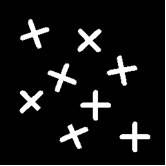
art8lab1.png: 
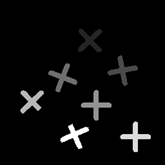
art8lab2.png: 
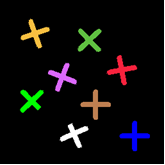
		

In [6]:
#Pergunta [Leonardo jesus]

#Por que minha apliccao deu errado para o art8lab 1 e 2 ?
#Seria um caso de problema com a vizinhanca ou leitura mesmo ?


import cv2
import numpy as np

def encontrarCC(imagem_binaria, vizinhanca=4):
    img = (imagem_binaria > 0).astype(np.int32)
    altura, largura = img.shape
    
    rotulos = np.zeros((altura, largura), dtype=np.int32)
    proximo_rotulo = 1

    if vizinhanca == 4:
        deslocamentos = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else: 
        deslocamentos = [(-1, 0), (1, 0), (0, -1), (0, 1),  
                         (-1, -1), (-1, 1), (1, -1), (1, 1)] 

    for y in range(altura):
        for x in range(largura):
            if img[y, x] == 1 and rotulos[y, x] == 0:
                
                fila = [(y, x)]
                rotulos[y, x] = proximo_rotulo
                
                while len(fila) > 0:
                    atual_y, atual_x = fila.pop(0)
                    
                    # Checa todos os vizinhos permitidos ao redor dele
                    for dy, dx in deslocamentos:
                        ny, nx = atual_y + dy, atual_x + dx
                        
                        if 0 <= ny < altura and 0 <= nx < largura:
                            if img[ny, nx] == 1 and rotulos[ny, nx] == 0:
                                rotulos[ny, nx] = proximo_rotulo 
                                fila.append((ny, nx))          
                
                # Terminou de inundar o componente atual? Passa para o próximo número
                proximo_rotulo += 1

    return rotulos

#Um detalhe importante é que a imagem original nao possui fundo totalente preto (0),
# o que faz com que a apkicacao usada para as proximas nao funcionasse nessa, assim tendo que definir um limiar

imagem_original = cv2.imread('art8.png', cv2.IMREAD_GRAYSCALE)
_, img_binaria = cv2.threshold(imagem_original, 127, 255, cv2.THRESH_BINARY)

# Executa para Vizinhança-4
matriz_v4 = encontrarCC(img_binaria, vizinhanca=4)
print(f"Vizinhança-4 para a figura original: {matriz_v4.max()} componentes encontrados.")

# Executa para Vizinhança-8
matriz_v8 = encontrarCC(img_binaria, vizinhanca=8)
print(f"Vizinhança-8 para a figura original: {matriz_v8.max()} componentes encontrados.")

# Agora resultados em cima das outras 2 imagens -----------------------------

#Art8lab1 a qual esta em tons de conza
imagem_art8lab1 = cv2.imread('art8lab1.png', cv2.IMREAD_GRAYSCALE)
img_binaria_art8lab1 = (imagem_art8lab1>0).astype(np.int32)

# Executa para Vizinhança-4
matriz_art8lab1_v4 = encontrarCC(img_binaria_art8lab1 , vizinhanca=4)
print(f"Vizinhança-4 para figura art8lab1: {matriz_art8lab1_v4.max()} componentes encontrados.")

# Executa para Vizinhança-8
matriz_art8lab1_v8 = encontrarCC(img_binaria_art8lab1 , vizinhanca=8)
print(f"Vizinhança-8 para figura art8lab1: {matriz_art8lab1_v8.max()} componentes encontrados.")

#----------------------------------------------------------------------------------------#

#Art8lab2
imagem_art8lab2 = cv2.imread('art8lab2.png', cv2.IMREAD_GRAYSCALE)
img_binaria_art8lab2 = (imagem_art8lab2>0).astype(np.int32)

# Executa para Vizinhança-4
matriz_art8lab2_v4 = encontrarCC(img_binaria_art8lab2 , vizinhanca=4)
print(f"Vizinhança-4 para figura art8lab2: {matriz_art8lab2_v4.max()} componentes encontrados.")

# Executa para Vizinhança-8
matriz_art8lab2_v8 = encontrarCC(img_binaria_art8lab2 , vizinhanca=8)
print(f"Vizinhança-8 para figura art8lab2: {matriz_art8lab2_v4.max()} componentes encontrados.")

Vizinhança-4 para a figura original: 9 componentes encontrados.
Vizinhança-8 para a figura original: 8 componentes encontrados.
Vizinhança-4 para figura art8lab1: 9 componentes encontrados.
Vizinhança-8 para figura art8lab1: 8 componentes encontrados.
Vizinhança-4 para figura art8lab2: 9 componentes encontrados.
Vizinhança-8 para figura art8lab2: 9 componentes encontrados.


2. Calcule o número de objetos da imagem clc3.png. Note que antes será necessário binarizar a imagem. Para isso, considere um limiar (*threshold*) de 67, isto é, valores acima de 167 na imagem original recebem zero, e os abaixo recebem 1 (o que resulta na imagem clc3thr1.png).

clc3.png
![clc3.png](clc3.png)
clc3thr1
![clc3thr1.png](clc3thr1.png)
clc3lab1
![clc3lab1.png](clc3lab1.png)
		

Numeor de Rotulos: 164
Número de objetos: 163


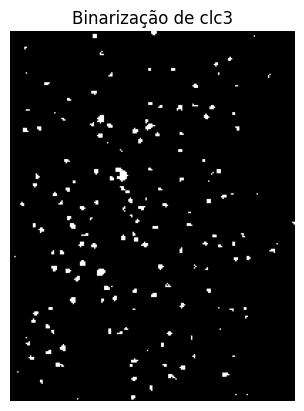

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# lê em escala de cinza
img = cv2.imread("clc3.png", cv2.IMREAD_GRAYSCALE)

# Binarização, fundo branco, objetos pretos
# 153 é um dos valores mais próximos para ficar parecido com clc3thr1
binaria = (img < 153).astype(np.uint8)

# Para o openCV, binaria está em 0/1, converter para 255
binaria_255 = binaria * 255

# Rotulação dos componentes conexos
# vizinhança=8 considera diagonais como conectadas
numRotulos, rotulos = cv2.connectedComponents(binaria_255, connectivity=8)

# label 0 é o fundo, então subtraímos 1
numObjetos = numRotulos - 1

# Resultado final
print("Numeor de Rotulos:", numRotulos)
print("Número de objetos:", numObjetos)

#### Resultado da binarização de clc3
plt.imshow(binaria * 255, cmap="gray")
plt.axis("off")
plt.title("Binarização de clc3")
plt.show()

# Auxiliares
#print("Tipo da imagem original:", img.dtype)
#print("Valores únicos da binária:", np.unique(binaria))
#print("valores únicos em rotulos:", np.unique(rotulos))
#print("formato de rotulos:", rotulos.shape)
#plt.imshow(img)

3. Calcule a distância média entre os objetos da imagem anterior. Mostre um histograma com as distâncias e o valor médio.

In [ ]:
# code here

4. Mostra a Transformada Distância da imagem do exercício 1